<a href="https://colab.research.google.com/github/subuhang/AI-and-Machine-Learning/blob/main/worksheet_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI & Machine Learning/FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/AI & Machine Learning"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")
print(os.listdir(extract_path))

Unzipped successfully!
['mnist_train.csv', 'mnist_dataset.csv', 'Iris.csv', 'FruitinAmazon.zip', 'FruitinAmazon']


In [ ]:
for root, dirs, files in os.walk("/content/FruitinAmazon"):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files[:5])
    print("-" * 50)

In [ ]:
train_dir = "/content/drive/MyDrive/AI & Machine Learning/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI & Machine Learning/FruitinAmazon/test"

class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [ ]:
sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random_image = random.choice(image_files)
    sample_images.append((class_name, os.path.join(class_path, random_image)))

print(sample_images)

[('acai', '/content/drive/MyDrive/AI & Machine Learning/FruitinAmazon/train/acai/images (14).jpeg'), ('cupuacu', '/content/drive/MyDrive/AI & Machine Learning/FruitinAmazon/train/cupuacu/download.jpeg'), ('graviola', '/content/drive/MyDrive/AI & Machine Learning/FruitinAmazon/train/graviola/images (1).jpeg'), ('guarana', '/content/drive/MyDrive/AI & Machine Learning/FruitinAmazon/train/guarana/images.jpeg'), ('pupunha', '/content/drive/MyDrive/AI & Machine Learning/FruitinAmazon/train/pupunha/images (7).jpeg'), ('tucuma', '/content/drive/MyDrive/AI & Machine Learning/FruitinAmazon/train/tucuma/images (6).jpeg')]


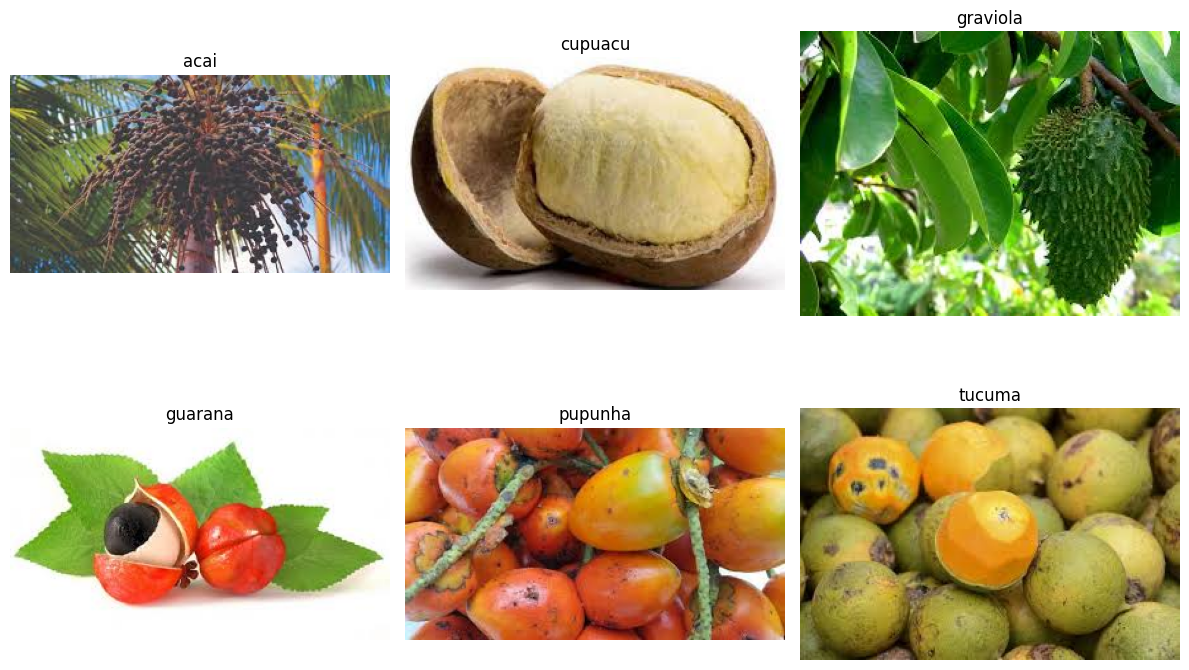

In [ ]:
plt.figure(figsize=(12, 8))

rows = 2
cols = 3

for i, (class_name, image_path) in enumerate(sample_images):
    img = Image.open(image_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def remove_corrupted_images(directory):
    corrupted_files = []

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            try:
                with Image.open(file_path) as img:
                    img.verify()
            except Exception:
                corrupted_files.append(file_path)
                os.remove(file_path)
                print("Removed corrupted image:", file_path)

    if not corrupted_files:
        print("No Corrupted Images Found.")

    return corrupted_files

In [ ]:
print("Checking train folder...")
train_corrupted = remove_corrupted_images(train_dir)

print("\nChecking test folder...")
test_corrupted = remove_corrupted_images(test_dir)

Checking train folder...
No Corrupted Images Found.

Checking test folder...
No Corrupted Images Found.


In [ ]:
print("Checking train folder...")
train_corrupted = remove_corrupted_images(train_dir)

print("\nChecking test folder...")
test_corrupted = remove_corrupted_images(test_dir)

Checking train folder...
No Corrupted Images Found.

Checking test folder...
No Corrupted Images Found.


In [ ]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 30 files belonging to 6 classes.


In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [ ]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_fruit_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.1361 - loss: 2.1013
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - accuracy: 0.1389 - loss: 2.1197 - val_accuracy: 0.0556 - val_loss: 1.6719
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.2611 - loss: 1.7923
Epoch 2: val_accuracy improved from 0.05556 to 0.11111, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step - accuracy: 0.3056 - loss: 1.7697 - val_accuracy: 0.1111 - val_loss: 1.7453
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.2750 - loss: 1.7259
Epoch 3: val_accuracy improved from 0.11111 to 0.83333, saving model to best_fruit_model.h5



Epoch 3: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 504ms/step - accuracy: 0.2917 - loss: 1.6942 - val_accuracy: 0.8333 - val_loss: 1.3856
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.4017 - loss: 1.5256
Epoch 4: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 414ms/step - accuracy: 0.3889 - loss: 1.5032 - val_accuracy: 0.7222 - val_loss: 1.2963
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.5451 - loss: 1.2793
Epoch 5: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step - accuracy: 0.5694 - loss: 1.2097 - val_accuracy: 0.6111 - val_loss: 1.0019
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7219 - loss: 0.9197
Epoch 6: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 0.7083 - loss: 0.8597 - val_accuracy: 0.7222 - val_loss: 0.7813
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7983 - loss:


Epoch 16: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step - accuracy: 0.9444 - loss: 0.1603 - val_accuracy: 0.8889 - val_loss: 0.3644
Epoch 17/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 1.0000 - loss: 0.0486
Epoch 17: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - accuracy: 1.0000 - loss: 0.0476 - val_accuracy: 0.7778 - val_loss: 0.5828
Epoch 18/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9899 - loss: 0.0345
Epoch 18: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - accuracy: 0.9861 - loss: 0.0400 - val_accuracy: 0.7778 - val_loss: 0.8093
Epoch 19/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 1.0000 - loss: 0.0232
Epoch 19: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step - accuracy: 1.0000 - loss: 0.0224 - val_accuracy: 0.7778 - val_loss: 0.6312
Epoch 20/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 1.0000

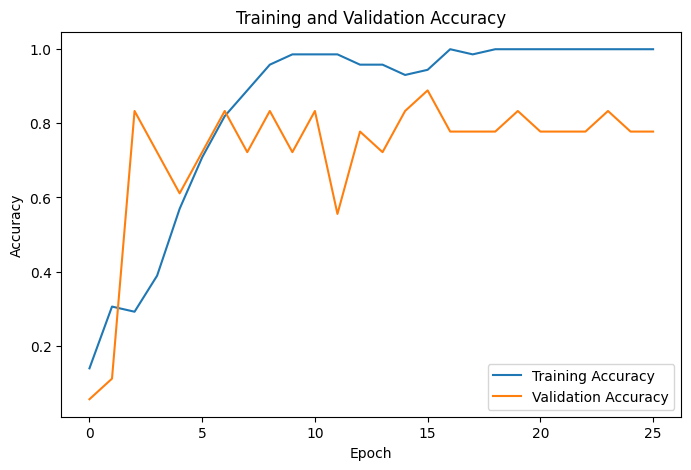

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

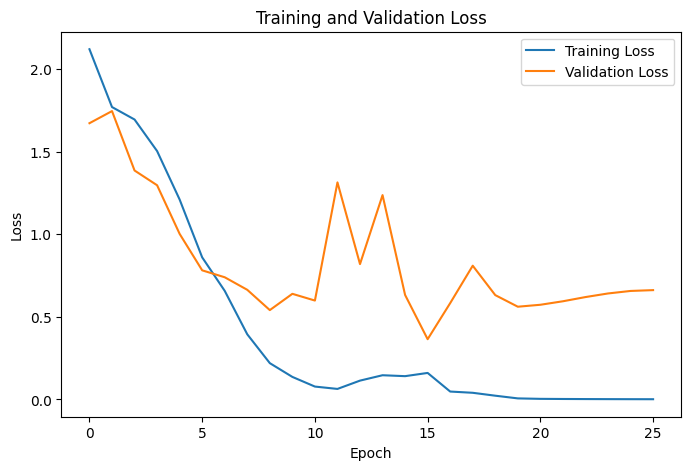

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6667 - loss: 0.9574
Test Loss: 0.9574335813522339
Test Accuracy: 0.6666666865348816


In [ ]:
model.save("fruit_classifier_final.h5")
print("Model saved successfully.")

Model saved successfully.


In [ ]:
loaded_model = tf.keras.models.load_model("fruit_classifier_final.h5")
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)
print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.6667 - loss: 0.9574
Loaded Model Test Loss: 0.9574335813522339
Loaded Model Test Accuracy: 0.6666666865348816


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       0.42      1.00      0.59         5
    graviola       1.00      0.60      0.75         5
     guarana       0.71      1.00      0.83         5
     pupunha       1.00      0.40      0.57         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.67        30
   macro avg       0.80      0.67      0.67        30
weighted avg       0.80      0.67      0.67        30



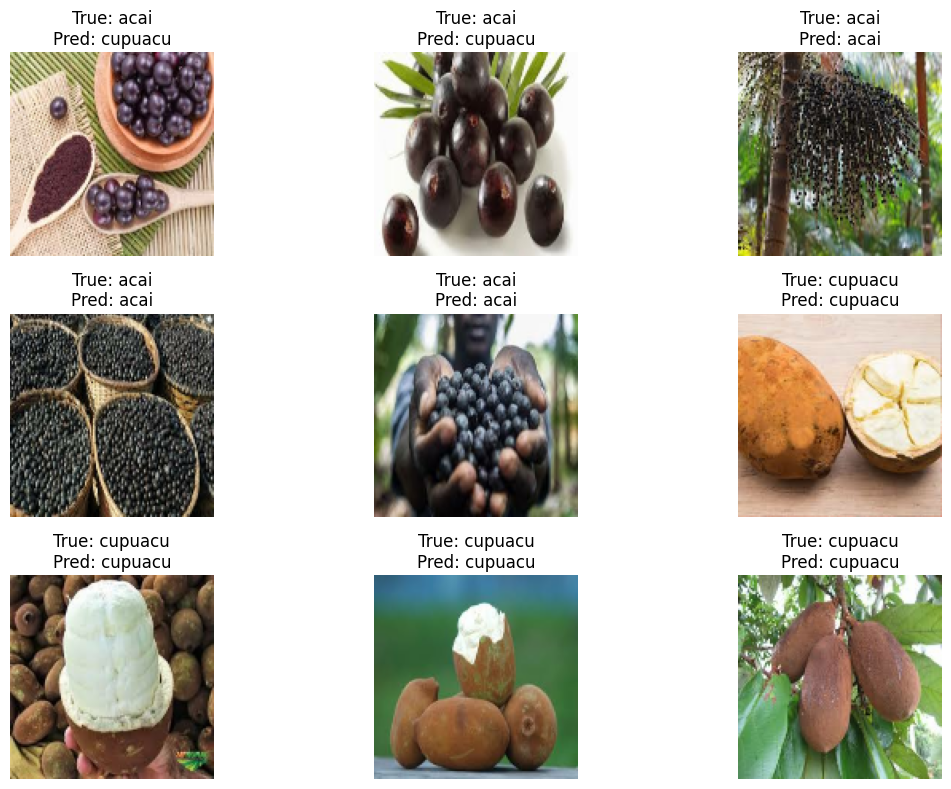

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted_labels[i]]}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os

if os.path.exists("fruit_classifier_final.h5"):
    print("Model file exists.")
    print("File name:", "fruit_classifier_final.h5")
    print("File size:", os.path.getsize("fruit_classifier_final.h5"), "bytes")
else:
    print("Model file not found.")

Model file exists.
File name: fruit_classifier_final.h5
File size: 25442992 bytes


In [ ]:
loaded_model = tf.keras.models.load_model("fruit_classifier_final.h5")
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,456 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)